# Introduction & Data Loading

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Game State Features →](02_game_state.ipynb)

This notebook introduces ODI win probability, the Cricsheet data format, and loads a famous match for exploration.


## ODI scoring recap

A standard ODI allots **50 overs** (300 balls) and **10 wickets** per innings. The team batting second must surpass the first-innings total to win.

| Symbol | Meaning |
|--------|--------|
| R | Runs scored so far |
| W | Wickets lost |
| B | Balls bowled |
| RRR | Runs required per remaining ball |

## What is win probability?

Win probability is **P(batting team wins | current game state)**. Broadcasters show it as a live gauge; analysts use it to quantify how dramatically a chase shifted. Required run rate (RRR) is a related heuristic but does not map cleanly to probability.

In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'

print('Ready:', DATA_DIR)


Ready: /Users/areeslindley/Documents/Git_repositories/projects-website/projects/cricket-win-probability/data


## Load a case-study match

We use bundled Cricsheet-format JSON from the 2019 World Cup Final.

In [2]:
match_path = SAMPLE_DIR / '2019_wc_final_eng_nz.json'
doc = load_cricsheet_json(match_path)
meta = match_metadata(doc)
balls = balls_to_dataframe(doc)
meta


{'match_id': 1,
 'teams': ['New Zealand', 'England'],
 'venue': 'Sample Ground',
 'city': 'Sample City',
 'event': 'ICC Cricket World Cup Final',
 'season': '2019',
 'date': '2019-07-14',
 'winner': 'England',
 'margin': {'wickets': 0},
 'outcome': {'winner': 'England', 'by': {'wickets': 0}},
 'match_type': 'ODI',
 'gender': 'male'}

## Ball-by-ball table

In [3]:
balls.head(10)


,innings,batting_team,bowling_team,over,ball_in_over,ball_number,runs_total,runs_batter,is_wicket,cumulative_runs,...,venue,city,event,season,date,winner,margin,outcome,match_type,gender
0,1,New Zealand,England,1,1,1,2,2,0,2,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
1,1,New Zealand,England,1,1,2,2,2,0,4,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
2,1,New Zealand,England,1,1,3,0,0,0,4,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
3,1,New Zealand,England,1,1,4,1,1,0,5,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
4,1,New Zealand,England,1,1,5,0,0,0,5,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
5,1,New Zealand,England,1,1,6,0,0,0,5,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
6,1,New Zealand,England,2,1,7,1,1,0,6,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
7,1,New Zealand,England,2,1,8,0,0,0,6,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
8,1,New Zealand,England,2,1,9,1,1,0,7,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male
9,1,New Zealand,England,2,1,10,2,2,0,9,...,Sample Ground,Sample City,ICC Cricket World Cup Final,2019,2019-07-14,England,{'wickets': 0},"{'winner': 'England', 'by': {'wickets': 0}}",ODI,male


## Cumulative runs by innings

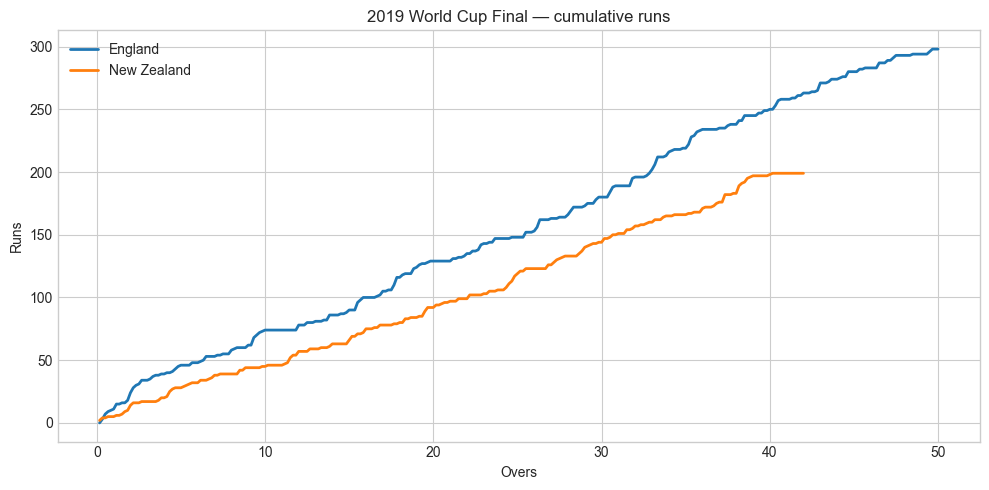

Saved /Users/areeslindley/Documents/Git_repositories/projects-website/projects/cricket-win-probability/figures/01_innings_runs.png


In [4]:
cum = cumulative_runs_by_innings(balls)
fig, ax = plt.subplots(figsize=(10, 5))
for label, grp in cum.groupby('innings_label'):
    ax.plot(grp['x'], grp['cumulative_runs'], label=label, linewidth=2)
ax.set_xlabel('Overs')
ax.set_ylabel('Runs')
ax.set_title('2019 World Cup Final — cumulative runs')
ax.legend()
plt.tight_layout()
fig_path = PROJ_DIR / 'figures' / '01_innings_runs.png'
fig_path.parent.mkdir(exist_ok=True)
fig.savefig(fig_path, dpi=120)
plt.show()
print(f'Saved {fig_path}')


## Preview

Each ball in the chase carries a binary outcome label: did the batting team eventually win? Later chapters model that probability from the live state.

In [5]:
states = build_game_states(doc)
print(f'Chase balls: {len(states)}')
print(f"Chase team won: {states['batting_team_won'].iloc[-1]}")
states[['ball_number', 'runs_scored', 'wickets_lost', 'runs_required', 'runs_required_per_ball']].tail()


Chase balls: 300
Chase team won: 1


,ball_number,runs_scored,wickets_lost,runs_required,runs_required_per_ball
295,296,294,7,0,0.0
296,297,296,7,0,0.0
297,298,298,7,0,0.0
298,299,298,7,0,0.0
299,300,298,7,0,0.0


---

**Navigation**: [← Previous: Project Overview](index.md) | [Next: Game State Features →](02_game_state.ipynb)
